In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from collections import Counter
import os

# Config
MAX_LEN = 130  # Độ dài tối đa của câu
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# 1. Load Data
train_df = pd.read_csv('../../data/processed/train.csv')
valid_df = pd.read_csv('../../data/processed/valid.csv')
# test_df = pd.read_csv('../../data/processed/test.csv')

print(f"Original Train size: {len(train_df)}")
print("Original Class Distribution:")
print(train_df['label_id'].value_counts())

# --- OVERSAMPLING (Nhân bản dữ liệu) ---
from sklearn.utils import resample

# Tách các lớp
df_0 = train_df[train_df.label_id == 0]
df_1 = train_df[train_df.label_id == 1]
df_2 = train_df[train_df.label_id == 2]

# Lấy số lượng mẫu của lớp nhiều nhất (thường là Lớp 0)
max_samples = len(df_0)

# Oversample lớp 1 và 2 để bằng lớp 0
df_1_upsampled = resample(df_1, 
                          replace=True,     # Cho phép lấy trùng lặp
                          n_samples=max_samples,    # Số lượng mẫu mong muốn
                          random_state=42) 

df_2_upsampled = resample(df_2, 
                          replace=True, 
                          n_samples=max_samples, 
                          random_state=42)

# Gộp lại thành tập train mới
train_df = pd.concat([df_0, df_1_upsampled, df_2_upsampled])

# Xáo trộn dữ liệu (Shuffle)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nUpsampled Train size: {len(train_df)}")
print("New Class Distribution:")
print(train_df['label_id'].value_counts())
# ---------------------------------------

print(f"\nValid size: {len(valid_df)}")

# 2. Build Vocabulary
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return str(text).lower().split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1
                
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

# Build vocab from training data
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(train_df['free_text'].tolist())
print(f"Vocab size: {len(vocab)}")

# 3. Dataset Class
class HateSpeechDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.df = df
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        text = row['free_text']
        label = row['label_id']
        
        numericalized_text = [self.vocab.stoi["<SOS>"]]
        numericalized_text += self.vocab.numericalize(text)
        numericalized_text.append(self.vocab.stoi["<EOS>"])
        
        # Padding/Truncating
        if len(numericalized_text) > self.max_len:
            numericalized_text = numericalized_text[:self.max_len]
        else:
            numericalized_text += [self.vocab.stoi["<PAD>"]] * (self.max_len - len(numericalized_text))
            
        return torch.tensor(numericalized_text), torch.tensor(label)

# Create DataLoaders
train_dataset = HateSpeechDataset(train_df, vocab, MAX_LEN)
valid_dataset = HateSpeechDataset(valid_df, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Check a batch
sample_x, sample_y = next(iter(train_loader))
print("Sample batch shape:", sample_x.shape, sample_y.shape)

Original Train size: 24048
Original Class Distribution:
label_id
0    19886
2     2556
1     1606
Name: count, dtype: int64

Upsampled Train size: 59658
New Class Distribution:
label_id
1    19886
2    19886
0    19886
Name: count, dtype: int64

Valid size: 2672
Vocab size: 13521
Sample batch shape: torch.Size([32, 130]) torch.Size([32])


In [4]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Tạo ma trận vị trí (Mathematics magic)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Thêm dimension batch: [max_len, 1, d_model] -> [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # Cộng embedding của từ với embedding vị trí
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class Transformer_Classifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_heads, n_layers, output_dim, max_len, dropout=0.3):
        super(Transformer_Classifier, self).__init__()
        
        # 1. Embedding Layer (Học từ đầu)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. Positional Encoding (Bắt buộc với Transformer)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_len, dropout)
        
        # 3. Transformer Encoder Block
        # d_model: kích thước vector (embedding_dim)
        # nhead: số lượng "đầu" chú ý (Multi-head Attention)
        # dim_feedforward: kích thước lớp ẩn bên trong
        encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim, nhead=n_heads, dim_feedforward=512, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 4. Classification Head
        self.fc = nn.Linear(embedding_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: [batch_size, max_len]
        
        # Tạo mask để che các vị trí padding (giá trị 0)
        # src_key_padding_mask: [batch_size, max_len] -> True ở nơi là padding
        padding_mask = (x == 0)

        # Embedding + Position
        x = self.embedding(x) * math.sqrt(x.size(-1)) # Scale embedding
        x = self.pos_encoder(x)
        
        # Qua Transformer Encoder
        # Output: [batch_size, max_len, embedding_dim]
        transformer_out = self.transformer_encoder(x, src_key_padding_mask=padding_mask)
        
        # Pooling: Masked Mean Pooling (Fix: Không tính padding vào trung bình)
        # padding_mask: True ở vị trí padding -> Đảo ngược thành False (0) cho padding, True (1) cho từ thật
        mask = (~padding_mask).unsqueeze(-1).float() # [batch_size, max_len, 1]
        
        # Tổng các vector từ (đã loại bỏ padding nhờ nhân với 0)
        sum_embeddings = torch.sum(transformer_out * mask, dim=1) # [batch_size, embedding_dim]
        
        # Đếm số lượng từ thật (tránh chia cho 0)
        sum_mask = torch.sum(mask, dim=1) # [batch_size, 1]
        sum_mask = torch.clamp(sum_mask, min=1e-9)
        
        out = sum_embeddings / sum_mask
        
        # Classification
        out = self.dropout(out)
        logits = self.fc(out)
        
        return logits

In [5]:
# Cấu hình cho Tiny Transformer (Nhỏ gọn để tránh overfit)
model = Transformer_Classifier(
        vocab_size=len(vocab), # Sử dụng len(vocab) từ class Vocabulary
        embedding_dim=128,   # Kích thước vector (bội số của n_heads)
        n_heads=4,           # 4 đầu chú ý
        n_layers=2,          # Chỉ dùng 2 lớp encoder (BERT base dùng 12)
        output_dim=3,        # 3 nhãn
        max_len=MAX_LEN,
        dropout=0.3)

model = model.to(DEVICE)
print(model)

# Đếm số lượng tham số
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

Transformer_Classifier(
  (embedding): Embedding(13521, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
The model has 2,1

In [6]:
# 5. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    for batch_x, batch_y in iterator:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        
        optimizer.zero_grad()
        
        predictions = model(batch_x)
        
        loss = criterion(predictions, batch_y)
        
        # Calculate accuracy
        _, preds = torch.max(predictions, 1)
        acc = (preds == batch_y).float().mean()
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for batch_x, batch_y in iterator:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            
            _, preds = torch.max(predictions, 1)
            acc = (preds == batch_y).float().mean()

            epoch_loss += loss.item()
            epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# 6. Training Loop
best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tiny_transformer_model.pt')
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

print("Training complete!")

c:\Users\hsvie\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch: 01
	Train Loss: 0.899 | Train Acc: 56.13%
	 Val. Loss: 1.117 |  Val. Acc: 61.98%
Epoch: 02
	Train Loss: 0.795 | Train Acc: 63.16%
	 Val. Loss: 1.063 |  Val. Acc: 71.09%
Epoch: 03
	Train Loss: 0.738 | Train Acc: 66.61%
	 Val. Loss: 1.130 |  Val. Acc: 69.61%
Epoch: 04
	Train Loss: 0.696 | Train Acc: 69.16%
	 Val. Loss: 1.122 |  Val. Acc: 71.35%
Epoch: 05
	Train Loss: 0.664 | Train Acc: 71.04%
	 Val. Loss: 1.149 |  Val. Acc: 70.91%
Epoch: 06
	Train Loss: 0.629 | Train Acc: 73.08%
	 Val. Loss: 1.108 |  Val. Acc: 73.92%
Epoch: 07
	Train Loss: 0.593 | Train Acc: 74.92%
	 Val. Loss: 1.140 |  Val. Acc: 73.81%
Epoch: 08
	Train Loss: 0.566 | Train Acc: 76.51%
	 Val. Loss: 1.154 |  Val. Acc: 73.88%
Epoch: 09
	Train Loss: 0.540 | Train Acc: 77.76%
	 Val. Loss: 1.149 |  Val. Acc: 76.26%
Epoch: 10
	Train Loss: 0.515 | Train Acc: 79.09%
	 Val. Loss: 1.145 |  Val. Acc: 75.19%
Training complete!


Accuracy: 0.7234
Precision per class: [0.86820365 0.1554878  0.32586558]
Recall per class:    [0.81452776 0.34459459 0.23255814]
F1 per class:        [0.84050963 0.21428571 0.27141645]
Macro Precision: 0.4499, Macro Recall: 0.4639, Macro F1: 0.4421

Classification report:

              precision    recall  f1-score   support

           0     0.8682    0.8145    0.8405      5548
           1     0.1555    0.3446    0.2143       444
           2     0.3259    0.2326    0.2714       688

    accuracy                         0.7234      6680
   macro avg     0.4499    0.4639    0.4421      6680
weighted avg     0.7650    0.7234    0.7403      6680



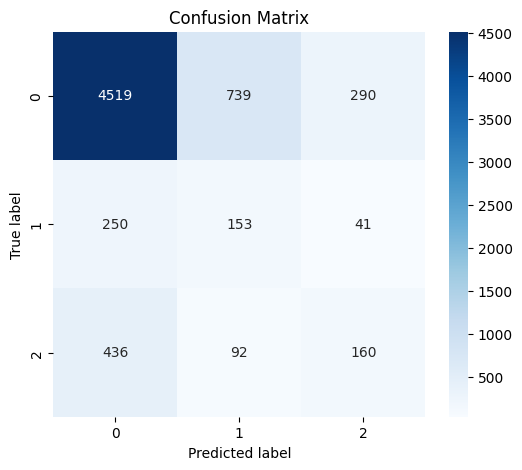

In [7]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns

# Đánh giá trên test set và vẽ confusion matrix
import matplotlib.pyplot as plt

# 1. Load test data
test_path = '../../data/processed/test.csv'
test_df = pd.read_csv(test_path)
test_dataset = HateSpeechDataset(test_df, vocab, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Load best model weights nếu có
if os.path.exists('tiny_transformer_model.pt'):
    model.load_state_dict(torch.load('tiny_transformer_model.pt', map_location=DEVICE))
model.to(DEVICE)
model.eval()

# 3. Collect predictions
y_true = []
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(batch_y.numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

# 4. Metrics
acc = accuracy_score(y_true, y_pred)
prec_per_class, rec_per_class, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2], zero_division=0)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision per class: {prec_per_class}")
print(f"Recall per class:    {rec_per_class}")
print(f"F1 per class:        {f1_per_class}")
print(f"Macro Precision: {prec_macro:.4f}, Macro Recall: {rec_macro:.4f}, Macro F1: {f1_macro:.4f}\n")

print("Classification report:\n")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# 5. Confusion matrix plot
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()